<div style="text-align: center; padding: 20px; border-radius: 10px;">
    <h1 style="color: #ffffff; font-size: 36px; font-weight: bold; text-shadow: 2px 2px 6px #2980b9;">
        🤖🏗️ Model Building 📈📉
    </h1>
</div>

<div style="
    font-family: Arial, sans-serif;
    font-size: 24px;
    font-weight: bold;
    text-shadow: 4px 4px 10px rgba(52, 152, 219, 0.8);
    color: #ffffff;">
   🤖 Overview
</div>

<p style="padding: 10px; border-radius: 10px; font-size: 16px; color: #7f8c8d;"> 
    This section focuses on the construction and training of predictive models to forecast NVIDIA stock prices using historical price data and technical indicators.
</p>

<div style="
    font-family: Arial, sans-serif;
    font-size: 24px;
    font-weight: bold;
    text-shadow: 4px 4px 10px rgba(52, 152, 219, 0.8);
    color: #ffffff;">
   📂 Packages
</div>
<p style="font-size: 18px; color: #f1f1f1; background: #2c3e50; padding: 15px; border-radius: 10px;">
    📥 <strong>Now we gonna import all the packages that we need to construct the model for the database</strong>
</p>

In [0]:
%pip install numpy==1.22.4 --force-reinstall
%pip install scipy==1.7.3 --force-reinstall
%pip install matplotlib==3.7.1 --force-reinstall
%pip install tensorflow==2.12.0 --force-reinstall
%pip install prophet seaborn

In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import last, col, when, isnan, percentile_approx, to_date, year, month, date_trunc, avg, lag, mean, stddev, sum, count, lit, to_timestamp, first
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType, FloatType
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.functions import vector_to_array

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

from datetime import timedelta, datetime
import plotly.graph_objects as go
import plotly.express as px

from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import SimpleRNN

from sklearn.metrics import mean_squared_error, mean_absolute_error

<div style="
    font-family: Arial, sans-serif;
    font-size: 24px;
    font-weight: bold;
    text-shadow: 4px 4px 10px rgba(52, 152, 219, 0.8);
    color: #ffffff;">
   📂 Load dataset
</div>

In [0]:
df_data = spark.sql("SELECT * FROM nvidia_data")

In [0]:
df_data = df_data.select("Date", "Close_NVDA", "Open_NVDA", "Volume_NVDA")
df_data = df_data.withColumn("Date", to_date(col("Date"))) \
       .withColumn("Close", col("Close_NVDA").cast(DoubleType()))

In [0]:
# only going to use the Close feature to predict
columns_to_keep = ['Date', 'Close']
feature_cols = ['Close']
df_data = df_data.select(columns_to_keep)

In [0]:
# display(df.limit(5))

### RNN


In [0]:
df = df_data.filter("Date <= '2024-12-31'")
df_test = df_data.filter("Date >= '2025-01-01'")

In [0]:
display(df_test)

Date,Close
2025-01-02,138.29727172851562
2025-01-03,144.4567108154297
2025-01-06,149.41624450683594
2025-01-07,140.12710571289062
2025-01-08,140.0971221923828
2025-01-10,135.8975067138672
2025-01-13,133.21774291992188
2025-01-14,131.7478790283203
2025-01-15,136.22747802734375
2025-01-16,133.55772399902344


In [0]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_vector")

train_assembled = assembler.transform(df)
test_assembled = assembler.transform(df_test)

scaler = MinMaxScaler(inputCol="features_vector", outputCol="scaled_features")

scaler_model = scaler.fit(train_assembled)
train_scaled = scaler_model.transform(train_assembled)
test_scaled = scaler_model.transform(test_assembled)

train_data = train_scaled.select("scaled_features", "Date").orderBy("Date").collect()
test_data = test_scaled.select("scaled_features", "Date").orderBy("Date").collect()

train_features = [row['scaled_features'].toArray().tolist() for row in train_data]
test_features = [row['scaled_features'].toArray().tolist() for row in test_data]

In [0]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i]) 
        y.append(data[i])
    return X, y

In [0]:
window_size = 60
X_train, y_train = create_sequences(train_features, window_size)
X_test, y_test = create_sequences(test_features, window_size)

In [0]:
model = Sequential()
model.add(SimpleRNN(window_size, input_shape=(window_size, 1), return_sequences=False))
model.add(Dense(1)) 

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=1)
rnn_predictions = model.predict(X_test)

Epoch 1/10
2765/6498 [===========>..................]

*** WARNING: max output size exceeded, skipping output. ***

1/1 [==============================] - 0s 132ms/step


In [0]:
# un-scale the results to be able to graph
stats = df.selectExpr("min(Close) as min_close", "max(Close) as max_close").collect()[0]
close_min = stats["min_close"]
close_max = stats["max_close"]

rnn_predictions = [(pred[0] * (close_max - close_min) + close_min) for pred in rnn_predictions]

### Prophet

In [0]:
ds_y_rdd = df.select("Date", "Close").rdd.map(
    lambda row: (row["Date"].strftime("%Y-%m-%d"), float(row["Close"]))
)

ds_list, y_list = zip(*ds_y_rdd.collect())

prophet_data = [{"ds": ds, "y": y} for ds, y in zip(ds_list, y_list)]

prophet_df = pd.DataFrame(prophet_data)

In [0]:
model_prophet = Prophet()
model_prophet.fit(prophet_df)

test_pd = df_test.select(col("Date").alias("ds")).toPandas()
test_pd['ds'] = pd.to_datetime(test_pd['ds'])

forecast = model_prophet.predict(test_pd)

16:16:13 - cmdstanpy - INFO - Chain [1] start processing
16:16:14 - cmdstanpy - INFO - Chain [1] done processing


### Graph

In [0]:
test = df_test.toPandas()

In [0]:
test.shape

Out[78]: (58, 2)

In [0]:
len(rnn_predictions)

Out[77]: 28

In [0]:
# rnn_predictions_flat = rnn_predictions.flatten()
start = test.shape[0] - len(rnn_predictions)

df_rnn_pred = pd.DataFrame({
    'Date': test['Date'].values[start:],
    'RNN_Pred': rnn_predictions
})


In [0]:
df_prophet_pred = forecast.rename(columns={'ds': 'Date', 'yhat': 'Prophet_Pred'})[['Date', 'Prophet_Pred']]


In [0]:
test['Date'] = pd.to_datetime(test['Date'].iloc[start:])
df_rnn_pred['Date'] = pd.to_datetime(df_rnn_pred['Date'])
df_prophet_pred['Date'] = pd.to_datetime(df_prophet_pred['Date'])

df_combined = pd.merge(test, df_rnn_pred, on='Date', how='left')
df_combined = pd.merge(df_combined, df_prophet_pred, on='Date', how='left')


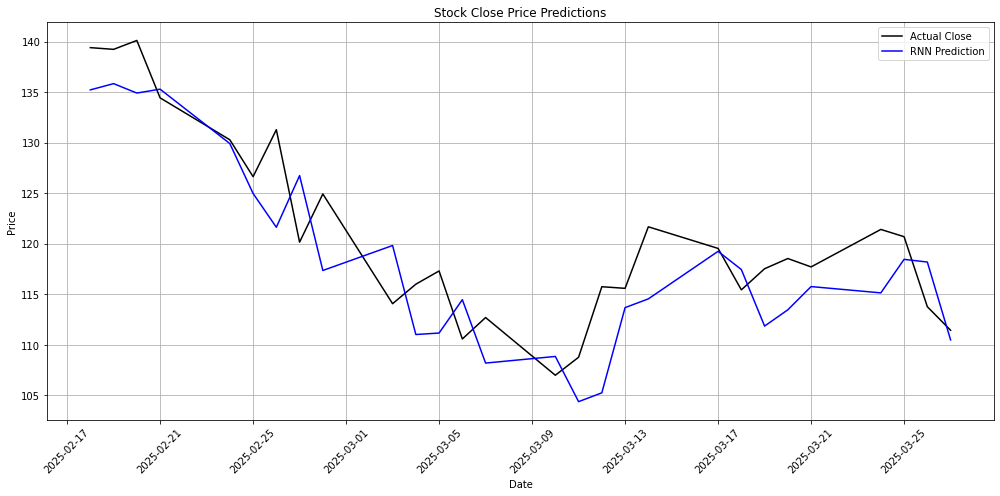

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))
plt.plot(df_combined['Date'], df_combined['Close'], label='Actual Close', color='black')
plt.plot(df_combined['Date'], df_combined['RNN_Pred'], label='RNN Prediction', color='blue')
# plt.plot(df_combined['Date'], df_combined['Prophet_Pred'], label='Prophet Forecast', color='green', linestyle='--')

plt.title('Stock Close Price Predictions')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
